# NBA Shot Decision Optimizer: Model Training & Evaluation

In this notebook, we train our **Logistic Regression Model** to predict the probability of a shot being made ($P(\text{Make})$).

Afterward, we perform a detailed evaluation that goes beyond simple accuracy. We check if our model can accurately predict actual game scores (xPts) and if the predicted probabilities are realistic (Calibration).

### Table of Contents
1.  **Setup & Data Loading**: Importing utils and loading the feature-engineered dataset.
2.  **Preprocessing**: Cleaning and splitting into Training (Past) and Test (Current Season).
3.  **Model Pipeline**: Building the pipeline (Imputation, Scaling, Encoding, Training).
4.  **Standard Metrics**: Accuracy and ROC-AUC.
5.  **Advanced Evaluation (xPts)**: Aggregation at the Game Level (Business Value Check).
6.  **Calibration**: Checking probability reliability (Reliability Diagram).
7.  **Deep Dive**: Probability Distribution by Shot Zone


In [1]:
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

# Add root directory to path to allow importing 'utils'
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# Import our custom modules
from utils import logreg_modeling_utils

# Pandas settings for better readability
pd.set_option('display.max_columns', None)

print("Setup complete. Utils loaded.")

Setup complete. Utils loaded.


---

## Quick Recap: From EDA Insights to Predictive Modeling

![fg perc plot](images/fg_perc_eda.png)


The visualization above summarizes the key takeaways from our **Exploratory Data Analysis (EDA)**. It visually confirms that shot success is not random—it is heavily influenced by measurable factors such as shot distance, specific court zones, and player efficiency.

However, while the EDA helps us *understand* historical patterns, it doesn't give us a tool for real-time decision-making. To do that, we need to quantify these relationships.

**In this notebook, we transition from observing data to modeling it:**

1.  **Data Loading:** We ingest the feature-engineered dataset that contains the metrics highlighted in the charts above.
2.  **Chronological Split:** To simulate a real-world scenario, we will not split the data randomly. Instead, we train on the **Past** and test on the **Future** (Current Season).
3.  **Logistic Regression:** We will train a model to calculate the exact probability ($P(\text{Make})$) for every shot, creating the foundation for our **Expected Points (xPts)** metric.

---

## 1. Load Data
We load the dataset created in the previous step (`feature_engineering`). This dataset already contains all calculated metrics like `PLAYER_ZONE_FG_PCT`, `SHOTCLOCK`, and `OPP_DEF_STRENGTH`.

In [2]:
# Path to file (from Feature Engineering step)
INPUT_FILE = '../data/processed/nba_processed_shot_data.parquet'

print(f"Loading data from: {INPUT_FILE} ...")
if not os.path.exists(INPUT_FILE):
    print(f"Error: File not found: {INPUT_FILE}")
else:
    df = pd.read_parquet(INPUT_FILE)
    print(f"Dataset loaded: {len(df)} shots.")

Loading data from: ../data/processed/nba_processed_shot_data.parquet ...
Dataset loaded: 1293360 shots.


---

## 2. Preprocessing & Split

Before training, we need to prepare the data carefully to ensure the model learns valid patterns, not noise or "cheats."

1.  **Cleaning & Feature Selection:** We remove specific columns for three main reasons:
    * **Generalization (Metadata):** We drop `GAME_ID`, `PLAYER_NAME`, and `TEAM_NAME`. The model should learn **what** constitutes a good shot (e.g., "Open Corner 3"), not memorize that Stephen Curry is a good shooter. (We use his stats, like `PLAYER_ZONE_FG_PCT`, to capture his skill instead).
    * **Data Leakage:** We must remove columns like `EVENT_TYPE` (which contains text like "Missed Shot"). If we left this in, the model would simply read the answer instead of predicting it.
    * **Redundancy:** We remove raw coordinates like `LOC_X` and `LOC_Y` because we have already converted them into better features: `SHOT_DISTANCE` and `SHOT_ANGLE`.

2.  **Chronological Split:** We must not split the data randomly. To simulate the real world, we train on the **Past** (Seasons up to 2024) and test on the **Future** (Season 2024-25).

In [3]:
df_model = logreg_modeling_utils.clean_data_for_training(df)
print(f"Features for model ({len(df_model.columns)}):")
print(df_model.columns.tolist())

SPLIT_SEASON = '2024-25'

print(f"\nSplitting data based on Season ID...")
X_train, y_train, X_test, y_test = logreg_modeling_utils.split_data_by_season(
    df_model,
    split_season=SPLIT_SEASON
)

print(f"Training Size: {len(X_train)} shots")
print(f"Test Size:     {len(X_test)} shots (Season {SPLIT_SEASON})")

Features for model (18):
['PERIOD', 'ACTION_TYPE', 'SHOT_DISTANCE', 'SHOT_MADE_FLAG', 'GAME_DATE', 'SEASON', 'CUSTOM_SHOT_ZONE', 'SHOT_ANGLE', 'SHOT_VALUE', 'TIME_REMAINING', 'PLAYER_SEASON_FG_PCT', 'PLAYER_ZONE_FG_PCT', 'LAST_5_SHOTS_MADE', 'PLAYER_LAST_100_FG_PCT', 'OPP_DEF_STRENGTH', 'SHOTCLOCK', 'PLAYER_HEIGHT_CM', 'PLAYER_POSITION']

Splitting data based on Season ID...
Splitting data. Split Season: 2024-25
Train Set Seasons: ['2019-20', '2020-21', '2021-22', '2022-23', '2023-24'] (1031741 shots)
Test Set Seasons:  ['2024-25', '2025-26'] (261619 shots)
Training Size: 1031741 shots
Test Size:     261619 shots (Season 2024-25)


---

## 3. Model Pipeline & Training

We use **Logistic Regression**. However, instead of just training it once, we use **Grid Search with 5-Fold Cross-Validation**.

**Why do we do this?**
1.  **Robustness (Cross-Validation):** We split the training data into 5 parts (folds). We train on 4 and validate on 1, repeating this 5 times. This ensures the model's performance is consistent and not just "lucky" with one specific data split.
2.  **Hyperparameter Tuning (Grid Search):** We test different values for the **Regularization Parameter (`C`)**.
    * **Small C:** Strong regularization (forces the model to be simple/conservative).
    * **Large C:** Weak regularization (allows the model to fit complex details).
    * **Goal:** Find the perfect balance to avoid Overfitting.

Since we have a mix of numerical (e.g., Distance) and categorical (e.g., Position) data, we build a pipeline:

* **Numerical Features:**
    * **Imputation:** Missing values (e.g., Rookies with no stats) are filled with the mean.
    * **Scaling:** Values are normalized (StandardScaler) because Logistic Regression is sensitive to different scales (e.g., Distance 0-30 vs. Percentage 0-1).
* **Categorical Features:**
    * **One-Hot Encoding:** Text values (e.g., "Guard") are converted into binary columns (0/1).

In [4]:
# 1. Automatic detection of column types
num_feats, cat_feats = logreg_modeling_utils.get_feature_lists(X_train)

print(f"Building Pipeline (Numerical: {len(num_feats)}, Categorical: {len(cat_feats)})")

# 2. Build the base Pipeline (Untrained)
base_pipeline = logreg_modeling_utils.build_logistic_pipeline(num_feats, cat_feats)

# 3. Train using Grid Search & Cross-Validation
# This function finds the best 'C' parameter automatically.
best_model = logreg_modeling_utils.train_with_grid_search(base_pipeline, X_train, y_train)

print("Training complete! Best model selected.")

# Save Model
MODELS_DIR = '../models'  # Pfad zu deinem Ordner (ggf. anpassen)
MODEL_NAME = 'nba_logreg_model.joblib'
SAVE_PATH = os.path.join(MODELS_DIR, MODEL_NAME)

joblib.dump(best_model, SAVE_PATH)
print(f"Model saved successfully at: {SAVE_PATH}")

Building Pipeline (Numerical: 12, Categorical: 3)
Starting Grid Search with 3-Fold Cross-Validation...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best Parameter (C): 0.1
Best CV Log Loss:   0.6414
Training complete! Best model selected.
Model saved successfully at: ../models/nba_logreg_model.joblib


---

## 4. Standard Evaluation
Here we check classic Machine Learning metrics:
* **Accuracy:** How often is the model correct (Make or Miss)?
* **ROC-AUC:** How well can the model distinguish between sure makes and sure misses? (0.5 = Guessing, 1.0 = Perfect).
* **Log-Loss:** The primary metric for probability quality. It measures the "cost" of being wrong by penalizing confident errors heavily (e.g., if the model predicts a 90% chance of a make, but it misses, the penalty is high). Lower is better.

In [5]:
y_prob = logreg_modeling_utils.evaluate_model_metrics(best_model, X_test, y_test)


STANDARD MODEL METRICS
Log Loss: 0.6415
Accuracy: 0.6282
ROC-AUC:  0.6545

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.82      0.70    139332
           1       0.67      0.41      0.51    122287

    accuracy                           0.63    261619
   macro avg       0.64      0.61      0.60    261619
weighted avg       0.64      0.63      0.61    261619



#### **Takeaways from the metrics:**

**1. Log Loss (0.6415) – *The Most Critical Metric***
* **What it measures:** The "confidence" of the model. It penalizes the model heavily if it predicts a 90% chance of making a shot, but the player misses.
* **Verdict:** This is a solid baseline for basketball data. Since shooting is inherently noisy (even open shots are often missed), we don't expect values near 0. A stable Log Loss means our **Expected Points (xPts)** calculations will be reliable over the long run, not fluctuating wildly.

**2. Accuracy (62.8%) – *Why it looks "low"***
* **What it measures:** How often the model correctly guessed "Make" or "Miss."
* **Verdict:** In sports analytics, ~60-65% is standard.
    * **The "Lucky Shot" Factor:** If a player forces a bad shot ($P(\text{Make}) = 20\%$) and gets lucky, the model predicts "Miss" (correctly identifying it as a bad decision), but gets marked "Wrong" on accuracy because the ball went in.
    * For **xPts**, we care that the model correctly identified it as a *bad decision* (20%), not whether the ball accidentally went in.

**3. ROC-AUC (0.6545) – *Ranking Ability***
* **What it measures:** How well the model separates "Easy Shots" from "Difficult Shots." (0.5 = Guessing, 1.0 = Perfect).
* **Verdict:** A score of **0.65** confirms that the model successfully distinguishes between high-quality and low-quality looks. It effectively ranks a wide-open dunk higher than a contested fadeaway, which is the core requirement for optimizing shot selection.

**Summary:**
While the model is conservative (it rarely predicts "Make" unless the shot is very good, as seen in the Recall of 0.41), this is actually **good for an optimizer**. We don't want to encourage bad shots just because they might go in by luck. The model prioritizes **shot quality** over random variance.

## 4.1 Feature Importance: What did the model learn?

### 4.1.1 Numerical Features
Since we are using **Logistic Regression**, we can open the "Black Box" and extract the coefficients. These numbers reveal the model's logic.

* A **high positive bar** means: "If this value is high, the shot is **more** likely to go in."
* A **high negative bar** means: "If this value is high, the shot is **less** likely to go in."

/var/folders/cb/5nvp6tkx4yvgwbrx2gmwn21m0000gn/T/ipykernel_7691/1418128603.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


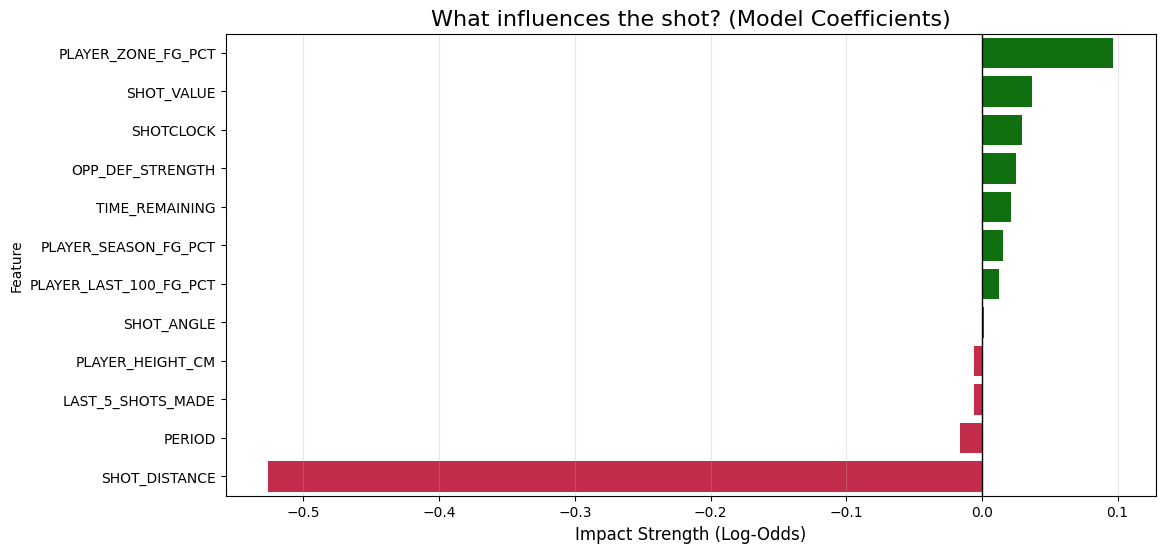

In [6]:
# Access the Classifier and Preprocessor steps from the pipeline
classifier = best_model.named_steps['classifier']
preprocessor = best_model.named_steps['preprocessor']

# Get names of numerical features
# (Note: We focus on numerical features here for clarity in the plot)
feature_names = num_feats

# Extract coefficients for numerical features
# Numerical features are the first block in the preprocessor, so we take the first N coefficients
# StandardScaling makes these directly comparable.

coeffs = classifier.coef_[0][:len(num_feats)]

# Create DataFrame for Plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance (Coefficient)': coeffs
})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance (Coefficient)', ascending=False)

# Plotting
plt.figure(figsize=(12, 6))
colors = ['green' if x > 0 else 'crimson' for x in importance_df['Importance (Coefficient)']]

sns.barplot(
    data=importance_df, 
    x='Importance (Coefficient)', 
    y='Feature', 
    palette=colors
)

plt.title("What influences the shot? (Model Coefficients)", fontsize=16)
plt.xlabel("Impact Strength (Log-Odds)", fontsize=12)
plt.grid(True, axis='x', alpha=0.3)
plt.axvline(x=0, color='black', linewidth=1)
plt.show()

**Key insights from the numerical Data:**

1.  **Distance is the Killer (`SHOT_DISTANCE`):**
    The huge red bar at the bottom confirms our hypothesis in the EDA. Nothing lowers the hit probability as strongly as the distance to the basket. This is the dominant physical factor in basketball.

2.  **Skill beats Form (`PLAYER_ZONE_FG_PCT` vs. `SEASON_FG_PCT`):**
    The strongest positive factor is `PLAYER_ZONE_FG_PCT`. This means: The model doesn't just look at whether a player is *generally* good, but whether they are good *from this specific spot* on the court. That's the difference between a Steph Curry 3-pointer and a Giannis 3-pointer.

3.  **Don't Rush! (`SHOTCLOCK`):**
    The bar is positive. This means: The more time left on the shot clock, the more likely the shot is to go in. Last-second shots (Panic Shots) have a worse conversion rate.

4.  **The Myth of the "Hot Hand" (`LAST_5_SHOTS_MADE`):**
    This is a surprise! This feature counts **how many** of the previous 5 attempts were successful (0 to 5). The bar is slightly **negative** (red), meaning that as a player's recent make-count increases, the probability for the *next* shot actually drops slightly.
    *Interpretation:* When a player has made a lot of recent shots, they often become overconfident and take much more difficult shots ("Heat Checks"), or the defense starts double-teaming them. The model detects that a "hot streak" often leads to a subsequent drop in shot quality.
    
5.  **Fatigue (`PERIOD`):**
    The bar is negative. The later in the game (Period 4 vs. Period 1), the less likely the shot is to go in. Tired legs lead to short shots.

### 4.1.2 Categorical Feautures

While numerical features tell us "where" and "when," categorical features tell us **"how"** the shot was taken. Because we used One-Hot Encoding, each specific action (like a "Dunk" or a "Step Back") has its own coefficient. 

Below are the Top 10 positive and Top 10 negative categorical drivers:

/var/folders/cb/5nvp6tkx4yvgwbrx2gmwn21m0000gn/T/ipykernel_7691/1283423762.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


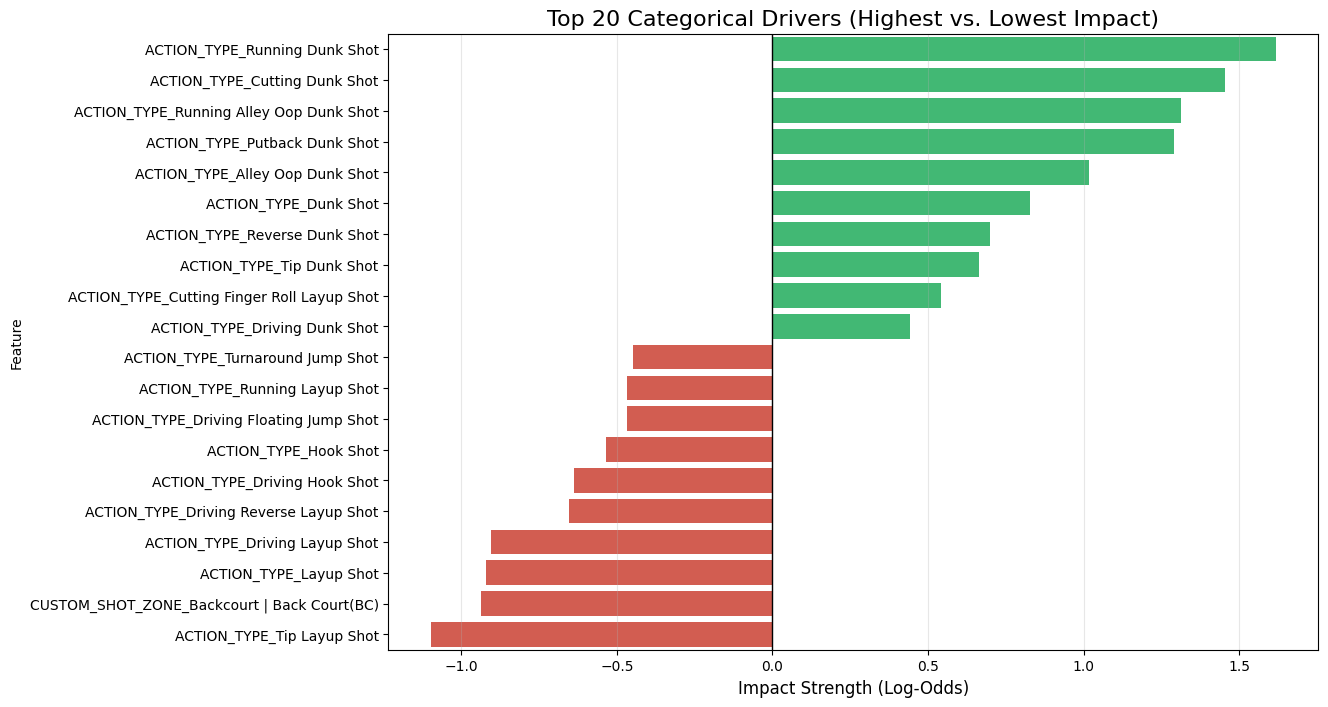

In [7]:
# Get the feature names from the OneHotEncoder (assigned to 'cat' in preprocessor)
cat_encoder = preprocessor.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(cat_feats)

# Categorical coefficients start after the numerical ones
cat_coeffs = classifier.coef_[0][len(num_feats):]

importance_cat_df = pd.DataFrame({
    'Feature': cat_feature_names,
    'Importance (Coefficient)': cat_coeffs
})

# Filter for the Top 10 positive and Top 10 negative impacts for clarity
top_pos = importance_cat_df.sort_values(by='Importance (Coefficient)', ascending=False).head(10)
top_neg = importance_cat_df.sort_values(by='Importance (Coefficient)', ascending=False).tail(10)
top_importance_df = pd.concat([top_pos, top_neg])

plt.figure(figsize=(12, 8))
colors_cat = ['#2ecc71' if x > 0 else '#e74c3c' for x in top_importance_df['Importance (Coefficient)']]

sns.barplot(
    data=top_importance_df, 
    x='Importance (Coefficient)', 
    y='Feature', 
    palette=colors_cat
)

plt.title("Top 20 Categorical Drivers (Highest vs. Lowest Impact)", fontsize=16)
plt.xlabel("Impact Strength (Log-Odds)", fontsize=12)
plt.grid(True, axis='x', alpha=0.3)
plt.axvline(x=0, color='black', linewidth=1)
plt.show()

**Key Insights from the Categorical Data:**

1.  **The Dominance of the Dunk:**
    As shown in the green bars, the top positive drivers are almost exclusively variations of dunks (e.g., `Running Dunk Shot`, `Cutting Dunk Shot`, `Alley Oop`). These shots have the highest impact strength, as they represent high-control attempts finished directly at the rim.
2.  **The Absence of `PLAYER_POSITION`:**
    Although `PLAYER_POSITION` was included as a categorical variable, it does **not** appear in the Top 20 influencers. This is a crucial finding: The model has learned that **what** is happening (the specific move) is far more important than **who** is doing it (their designated position). A "Running Dunk" is high-value whether it's finished by a Guard or a Center.
3.  **The Penalty for Difficulty:**
    The red bars reveal which shot types the model considers difficult. `Tip Layup Shots` and `Driving Layup Shots` carry negative coefficients. While these are close to the rim, they often occur under high defensive pressure or with less body control, which the model detects as a lower hit rate.
4.  **Geography Matters (`Backcourt | Back Court`):**
    The feature `CUSTOM_SHOT_ZONE_Backcourt` shows a significant negative impact. The model correctly learned that "full-court heaves" are statistically unlikely to result in points.

---

## 5. Advanced Evaluation: xPts & Game Totals
This is the most critical part for our project ("Shot Decision Optimizer").

We calculate **Expected Points (xPts)** for every shot:
$$xPts = P(\text{Make}) \times \text{Shot Value} (2 \text{ or } 3)$$

Then, we check if the sum of xPts for a game correlates with the actual final score. If our model is good, the Sum of xPts should be very close to the Real Score.


 Preparing Evaluation Dataframe...
   Evaluation DF ready. Preview:
            GAME_ID TEAM_ABBREVIATION  SHOT_VALUE  PROBABILITY_MAKE      xPts  \
1042565  0022400062               MIN           2          0.544152  1.088304   
1042559  0022400062               LAL           2          0.409803  0.819606   
1042564  0022400062               LAL           2          0.874046  1.748092   
1042563  0022400062               LAL           2          0.513304  1.026608   
1042562  0022400062               MIN           2          0.556106  1.112211   

         ACTUAL_POINTS  
1042565              0  
1042559              0  
1042564              2  
1042563              2  
1042562              0  

GAME-LEVEL EVALUATION (Sum of xPts)
Games Evaluated: 2,932
Mean Absolute Error (MAE): 8.84 points per game
Mean Squared Error (MSE):  122.01 points per game
R² Score (Correlation):    0.2046


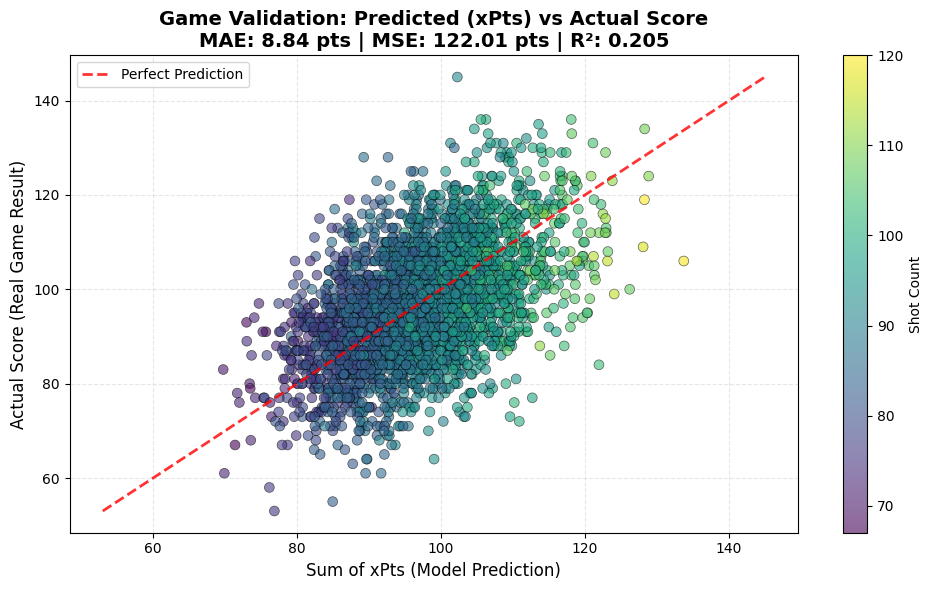

,GAME_ID,TEAM_ABBREVIATION,Predicted_Score,Actual_Score,Shot_Count
0,0022400001,ATL,102.026877,110,99
1,0022400001,BOS,80.837475,94,75
2,0022400002,DET,98.907134,99,92
3,0022400002,MIA,109.742902,111,101
4,0022400003,CHA,87.570442,81,84
...,...,...,...,...,...
2927,0022500266,PHI,106.933075,102,97
2928,0022500267,ATL,98.697480,118,87
2929,0022500267,SAS,104.352462,113,91
2930,0022500268,CHA,89.044968,93,85


In [8]:
print("\n Preparing Evaluation Dataframe...")

# 1. Prepare DataFrame for analysis
# Copy X_test and add predictions
df_eval = X_test.copy()
df_eval['PROBABILITY_MAKE'] = y_prob
df_eval['SHOT_MADE_FLAG'] = y_test

# 2. Restore Metadata (Game ID, Team, Shot Value)
# We need these for aggregation but dropped them before training.
# Fetch them from the original DataFrame (df) via index.
cols_to_restore = ['GAME_ID', 'TEAM_ABBREVIATION', 'SHOT_VALUE', 'GAME_EVENT_ID', 'SHOT_TYPE', 'LOC_Y', 'LOC_X']
for col in cols_to_restore:
    df_eval[col] = df.loc[df_eval.index, col]

# 3. Calculate xPts
df_eval = logreg_modeling_utils.calculate_xpts(df_eval)

print(f"   Evaluation DF ready. Preview:")
print(df_eval[['GAME_ID', 'TEAM_ABBREVIATION', 'SHOT_VALUE', 'PROBABILITY_MAKE', 'xPts', 'ACTUAL_POINTS']].head())

# 4. Aggregation per Game and Plotting
# Compare: Sum(xPts) vs. Sum(Actual Points)
logreg_modeling_utils.evaluate_game_totals(df_eval)

This scatter plot answers the question: **"Can our shot quality model actually predict game scores?"**

We aggregate the Expected Points (xPts) for every shot taken by a team in a game (X-Axis) and compare it to their actual final score (Y-Axis).

#### **Key Takeaways from the Plot:**

1.  **The Trend (Correlation):**
    The cloud of data points clearly follows the upward trend of the **red dashed line** (Perfect Prediction). This confirms the fundamental premise: Teams that generate higher quality shots (higher xPts) generally score more points.

2.  **The "Luck" Factor (Variance):**
    The spread of the blue dots around the line represents the inherent variance in basketball—often referred to as "Make/Miss variability."
    * **Points Above the Red Line:** The team **Overperformed**. They scored more than the model predicted, likely by making difficult, low-probability shots (e.g., "The Steph Curry Effect").
    * **Points Below the Red Line:** The team **Underperformed**. They generated good open looks (high xPts) but simply missed shots they would usually make (a "cold shooting night").

3.  **Model Performance ($R^2 \approx 0.20$):**
    Here we have an $R^2$ of roughly 0.20. It indicates that while shot selection is crucial, it only explains about 20% of the final score variance. The rest is determined by individual player skill, defensive pressure not captured by the data, and pure random chance.

---

## 6. Calibration (Reliability Diagram)
Here we check the quality of the probabilities ("Binning").
Similar to xGoals in soccer, we ask:
*"If the model predicts a 30% chance for a shot, did 30 out of 100 such shots actually go in?"*

We plot this separately for **All Shots**, **2-Pointers**, and **3-Pointers** to see if the model struggles with distance shots.


CALIBRATION EVALUATION (50 Bins)


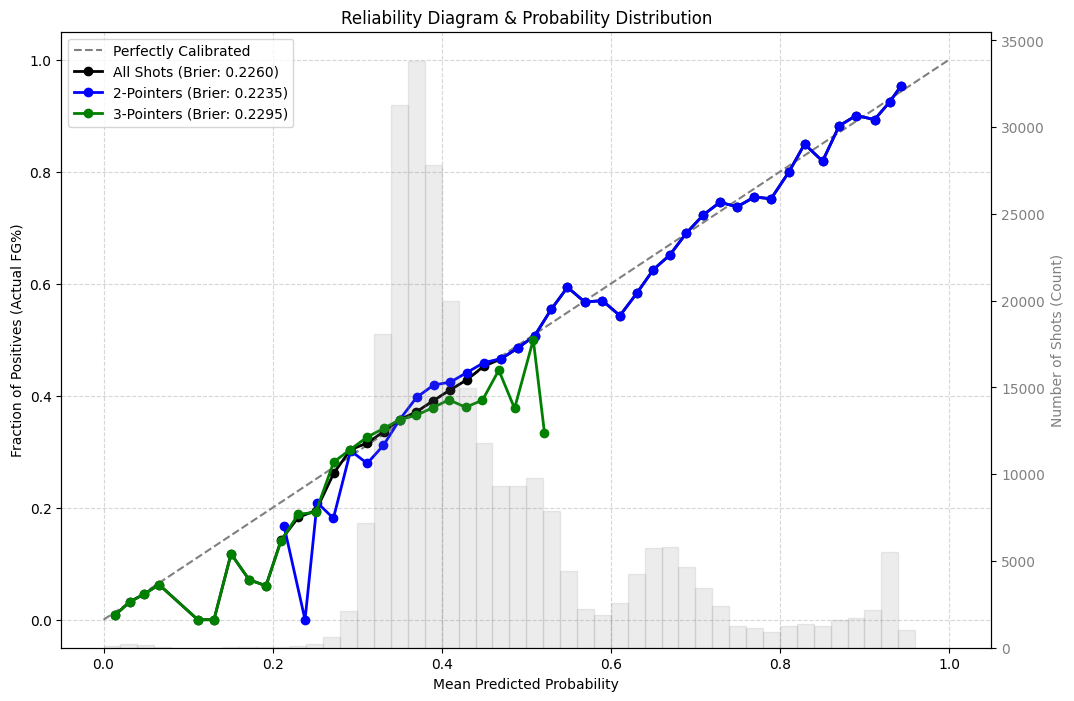


--- Detailed Bin Statistics (All Shots) ---
                Count  Avg_Pred_Prob  Actual_FG_Pct
prob_bin                                           
(-0.001, 0.02]    113       0.013973       0.008850
(0.02, 0.04]      221       0.030924       0.031674
(0.04, 0.06]      175       0.047783       0.045714
(0.06, 0.08]       16       0.065752       0.062500
(0.08, 0.1]         0            NaN            NaN
(0.1, 0.12]         7       0.111514       0.000000
(0.12, 0.14]       10       0.130602       0.000000
(0.14, 0.16]       17       0.150808       0.117647
(0.16, 0.18]       28       0.172186       0.071429
(0.18, 0.2]        33       0.192118       0.060606
(0.2, 0.22]        70       0.210172       0.142857
(0.22, 0.24]       71       0.230509       0.183099
(0.24, 0.26]      236       0.251262       0.194915
(0.26, 0.28]      624       0.272142       0.261218
(0.28, 0.3]      2136       0.291903       0.303371
(0.3, 0.32]      7203       0.311967       0.315702
(0.32, 0.34]    180

In [9]:
logreg_modeling_utils.evaluate_calibration(df_eval, n_bins=50)

#### **Key Takeaways: Is the Model Honest?**

1.  **High Reliability (Trustworthiness):**
    The most important finding is that the curves (colored lines) hug the dotted diagonal closely, especially in the **20% to 60% probability range**.
    * *Significance:* This confirms that our **xPts** metric is real. When the model predicts a 40% chance of scoring, historical data confirms that ~40% of those shots actually go in. The model is neither overconfident nor underconfident.

2.  **The "Battleground" (High Volume Zone):**
    The gray histogram in the background shows that the vast majority of NBA shots fall into the **35%–55% probability range**.
    * *Insight:* Basketball is rarely about "guaranteed" shots. Most attempts are contested or semi-open. Since our model is perfectly calibrated in this specific high-volume zone, it is highly effective for evaluating the most common game situations.

3.  **Noise at the Extremes (< 20%):**
    On the far left, the curves become jagged.
    * *Reason:* The histogram bars are nearly invisible here. These represent rare "desperate heaves" (e.g., full-court shots). The model struggles to draw a smooth curve simply because the sample size is too small, which creates statistical noise rather than a systemic error.

4.  **Unbiased Across Shot Types:**
    Crucially, the **2-Pointer (Blue)** and **3-Pointer (Green)** lines follow the same trajectory.
    * *Strategic Value:* The model does not "prefer" one shot type over the other. It evaluates a mid-range jumper and a corner three with the exact same strictness. This ensures that our **Shot Decision Optimizer** won't artificially bias recommendations toward 3-pointers unless the math truly supports it.

---

## 7. Deep Dive: Probability Distribution by Shot Zone

This boxplot is one of the most powerful visualizations for understanding the model's confidence.

We group all shots by their **Zone** (x-axis) and look at the **Predicted Probabilities** (y-axis). The zones are sorted from the highest median probability (left) to the lowest (right).


PROBABILITY DISTRIBUTION BY CUSTOM_SHOT_ZONE


/Users/furkan/Documents/Universität/5.Semster/shot-decision-optimizer/utils/logreg_modeling_utils.py:488: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


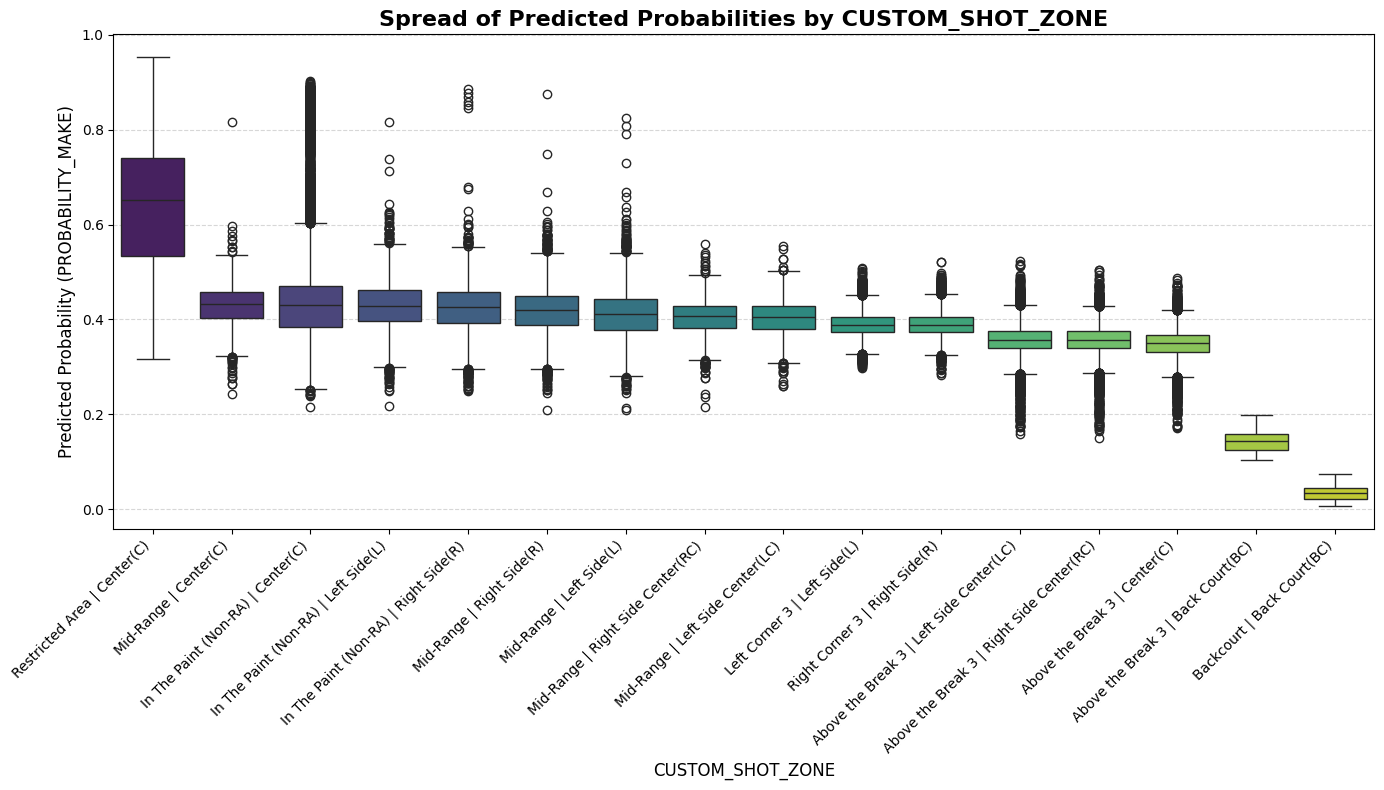

In [10]:
logreg_modeling_utils.evaluate_probability_distribution(
    df_eval, 
    feature_col='CUSTOM_SHOT_ZONE'
)

#### **Key Takeaways from the Plot:**

1.  **Restricted Area (High Variance):**
    Look at the first box on the left (`Restricted Area | Center(C)`). While it has the highest median (best chance of scoring), the box is remarkably **tall**.
    * *Interpretation:* The model distinguishes strongly here. It knows that an open dunk is a 95% shot, but a contested layup in traffic might only be a 35% shot. Context matters most here.

2.  **Mid-Range (The "Tough" Zone):**
    These shots hover around 40-45% probability. They are less efficient than rim shots but have a tighter spread, suggesting the model sees them as consistently "medium" difficulty shots.

3.  **3-Pointers (Consistency):**
    The boxes for 3-pointers (e.g., `Right Corner 3`, `Above the Break 3`) are comparatively **short/narrow**.
    * *Interpretation:* The model views most 3-pointers as having a similar probability (roughly 35-40%), regardless of the specific situation. Unlike layups, the model finds less variation in shot quality from beyond the arc.

4.  **Backcourt (The Impossible):**
    As expected, the box on the far right is compressed near 0%. The model knows these are virtually never successful.

---

## 8. Conclusion & Final Report: The Math Behind the Shot

We started this project with a simple question: **"Can we quantify the quality of a basketball shot?"**

By moving from raw shot charts to a probabilistic **Expected Points (xPts)** model, we have transformed binary outcomes (Made/Missed) into a continuous spectrum of shot quality.

### 1. What the Model Learned (The "Brain")
Our Logistic Regression model didn't just memorize stats; it learned the physics and psychology of the game:
* **Distance is Gravity:** As confirmed by our Feature Importance analysis, shot distance is the single biggest negative factor. The probability drops exponentially, not linearly, as players move away from the rim.
* **Skill Matters:** The feature `PLAYER_ZONE_FG_PCT` was the strongest positive driver. The model understands that a "bad shot" for a center might be a "great shot" for a superstar guard.
* **The "Hot Hand" is a Trap:** Interestingly, the model identified that players with many recent makes (`LAST_5_SHOTS_MADE`) often take lower-quality shots subsequently, leading to a slight dip in probability.


### 2. Reliability & Limitations (The Reality Check)
While the model passes standard checks, it is important to interpret the metrics correctly in the context of sports analytics:

* **Log Loss (0.64) over Accuracy (63%):**
    Our accuracy of ~63% might seem low compared to other industries, but in basketball, it is expected. The sport is inherently noisy—players make "bad" shots (Lucky Shots) and miss "perfect" shots.
    * Crucially, our **Log Loss of 0.64** indicates that the model is **stable**. It correctly penalizes overconfidence.
    * The model successfully prioritizes **Process over Outcome**: It correctly identifies a low-percentage shot as a "bad decision," even if it happened to go in this one time.

* **Game Validation Variance:**
    The scatter plot for Game Totals shows a clear correlation, but also significant spread ($R^2 \approx 0.20$). The model explains the *structural* part of the score (shot quality), while the remaining variance comes from defensive pressure (which we lack tracking data for) and pure random chance. The model is a useful strategic guide, not a crystal ball.


### 3. Strategic Takeaways (The "Why")
* **The Mid-Range Variance:** Our boxplots revealed that the Mid-Range is the most context-dependent zone. The gap between a "good" mid-range shot and a "bad" one is massive.
* **The 3-Point Consistency:** Conversely, 3-point probabilities are surprisingly consistent. The model suggests that creating volume from deep is often more reliable than hunting complex 2-point looks.
* **The "Sure Thing":** The Restricted Area remains the king of efficiency, but the model clearly distinguishes between open dunks (90%+) and contested layups in traffic (<40%).


---
**Final Verdict: A Stable Baseline for Decision Science**

We have successfully established a **robust quantitative baseline** for shot evaluation. While the model does not capture every nuance, its strong calibration confirms that it effectively isolates the *structural quality* of a shot from random noise. 

This model serves as a reliable foundation for our **Shot Decision Optimizer**, allowing us to shift the conversation from "Did it go in?" to "Was it the right decision?" based on data rather than just intuition.